### Predict accident_risk

In [1]:
# ==========================================================
# Full EDA + Modeling notebook for 'playground-series-s5e10'
# Predict accident_risk
# ==========================================================

import os
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

# Paths
INPUT_DIR = Path("/kaggle/input/playground-series-s5e10")
OUT_DIR = Path("/kaggle/working/eda_outputs")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# -------------------------
# 0. Imports
# -------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from plotly.subplots import make_subplots
import gc
%matplotlib inline
import plotly.graph_objects as go
import plotly.offline as pyo
from sklearn.model_selection import KFold
from sklearn.metrics import mean_squared_error
from sklearn.preprocessing import LabelEncoder, StandardScaler
import lightgbm as lgb

print("Libraries loaded")

# Set style for attractive visualizations
sns.set_style("darkgrid")
sns.set_palette("husl")
plt.rcParams['figure.figsize'] = (14, 7)
plt.rcParams['font.size'] = 10
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# -------------------------
# Load data
# -------------------------
train_path = INPUT_DIR / "train.csv"
test_path = INPUT_DIR / "test.csv"

train = pd.read_csv(train_path)
print("Loaded train:", train.shape)

if test_path.exists():
    test = pd.read_csv(test_path)
    print("Loaded test:", test.shape)
else:
    test = None
    print("Warning: test.csv not found — submission will not be created.")

Libraries loaded
Loaded train: (517754, 14)
Loaded test: (172585, 13)


### dataset overview

In [2]:
df = pd.read_csv("/kaggle/input/playground-series-s5e10/train.csv")

print("✅ Dataset Generated Successfully!")
print(f"Shape: {df.shape}")
print("\nColumn Information:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

✅ Dataset Generated Successfully!
Shape: (517754, 14)

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13 

In [3]:
test = pd.read_csv("/kaggle/input/playground-series-s5e10/test.csv")

print("✅ Dataset Generated Successfully!")
print(f"Shape: {df.shape}")
print("\nColumn Information:")
print(df.info())
print("\nFirst 5 rows:")
print(df.head())

✅ Dataset Generated Successfully!
Shape: (517754, 14)

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517754 entries, 0 to 517753
Data columns (total 14 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   id                      517754 non-null  int64  
 1   road_type               517754 non-null  object 
 2   num_lanes               517754 non-null  int64  
 3   curvature               517754 non-null  float64
 4   speed_limit             517754 non-null  int64  
 5   lighting                517754 non-null  object 
 6   weather                 517754 non-null  object 
 7   road_signs_present      517754 non-null  bool   
 8   public_road             517754 non-null  bool   
 9   time_of_day             517754 non-null  object 
 10  holiday                 517754 non-null  bool   
 11  school_season           517754 non-null  bool   
 12  num_reported_accidents  517754 non-null  int64  
 13 

### Basic statistics

In [4]:
print(f"Dataset Shape: {df.shape}")
print(f"Total Observations: {len(df)}")
print(f"Number of Features: {df.shape[1]}")

Dataset Shape: (517754, 14)
Total Observations: 517754
Number of Features: 14


### Missing values check

In [5]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
id                        0
road_type                 0
num_lanes                 0
curvature                 0
speed_limit               0
lighting                  0
weather                   0
road_signs_present        0
public_road               0
time_of_day               0
holiday                   0
school_season             0
num_reported_accidents    0
accident_risk             0
dtype: int64


### Data types

In [6]:
print("\nData Types:")
print(df.dtypes)


Data Types:
id                          int64
road_type                  object
num_lanes                   int64
curvature                 float64
speed_limit                 int64
lighting                   object
weather                    object
road_signs_present           bool
public_road                  bool
time_of_day                object
holiday                      bool
school_season                bool
num_reported_accidents      int64
accident_risk             float64
dtype: object


### Summary statistics for numerical columns

In [7]:
# Summary statistics for numerical columns
numerical_cols = ['id', 'num_lanes','speed_limit','curvature','num_reported_accidents','accident_risk']
print("\nSummary Statistics (Numerical Features):")
print(df[numerical_cols].describe())


Summary Statistics (Numerical Features):
                  id      num_lanes    speed_limit      curvature  \
count  517754.000000  517754.000000  517754.000000  517754.000000   
mean   258876.500000       2.491511      46.112575       0.488719   
std    149462.849974       1.120434      15.788521       0.272563   
min         0.000000       1.000000      25.000000       0.000000   
25%    129438.250000       1.000000      35.000000       0.260000   
50%    258876.500000       2.000000      45.000000       0.510000   
75%    388314.750000       3.000000      60.000000       0.710000   
max    517753.000000       4.000000      70.000000       1.000000   

       num_reported_accidents  accident_risk  
count           517754.000000  517754.000000  
mean                 1.187970       0.352377  
std                  0.895961       0.166417  
min                  0.000000       0.000000  
25%                  1.000000       0.230000  
50%                  1.000000       0.340000  
75%    

### TARGET VARIABLE ANALYSIS

In [8]:
# ============================================================================
#  TARGET VARIABLE ANALYSIS
# ============================================================================
print("\n" + "="*80)
print(" TARGET VARIABLE ANALYSIS (Accident Risk)")
print("="*80)

print(f"\n📈 Accident Risk Statistics:")
print(f"  Mean: {df['accident_risk'].mean():.4f}")
print(f"  Median: {df['accident_risk'].median():.4f}")
print(f"  Std Dev: {df['accident_risk'].std():.4f}")
print(f"  Min: {df['accident_risk'].min():.4f}")
print(f"  Max: {df['accident_risk'].max():.4f}")

# Accident count statistics
print(f"\n🚗 Number of Accidents Statistics:")
print(f"  Total Accidents: {df['num_reported_accidents'].sum():,}")
print(f"  Mean per segment: {df['num_reported_accidents'].mean():.2f}")
print(f"  Median per segment: {df['num_reported_accidents'].median():.0f}")
print(f"  Max in single segment: {df['num_reported_accidents'].max()}")



 TARGET VARIABLE ANALYSIS (Accident Risk)

📈 Accident Risk Statistics:
  Mean: 0.3524
  Median: 0.3400
  Std Dev: 0.1664
  Min: 0.0000
  Max: 1.0000

🚗 Number of Accidents Statistics:
  Total Accidents: 615,076
  Mean per segment: 1.19
  Median per segment: 1
  Max in single segment: 7


### INTERACTIVE  VISUALIZATIONS

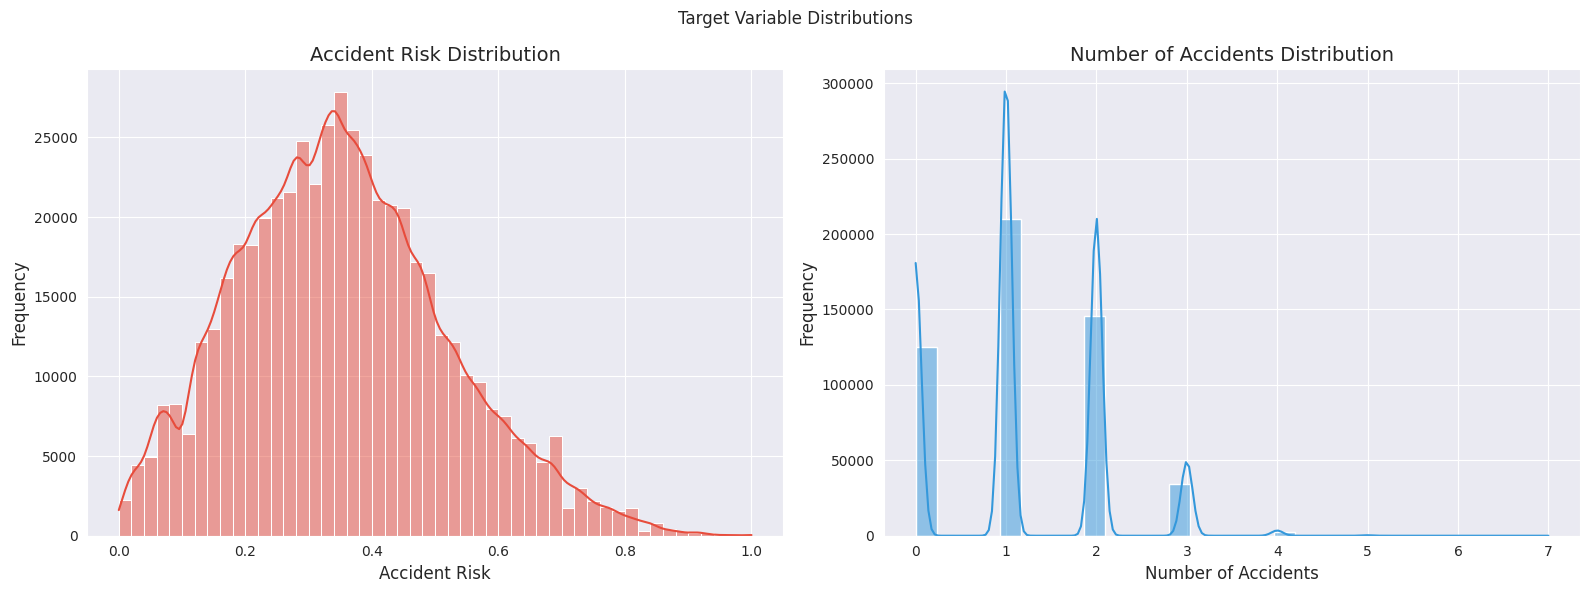

In [9]:
# ============================================================================
#  INTERACTIVE  VISUALIZATIONS
# ============================================================================

# Figure 1: Accident Risk Distribution & Number of Accidents Distribution
fig, axes = plt.subplots(1, 2, figsize=(16,6))
sns.histplot(df['accident_risk'], bins=50, color='#E74C3C', ax=axes[0], kde=True)
axes[0].set_title('Accident Risk Distribution')
axes[0].set_xlabel('Accident Risk')
axes[0].set_ylabel('Frequency')

sns.histplot(df['num_reported_accidents'], bins=30, color='#3498DB', ax=axes[1], kde=True)
axes[1].set_title('Number of Accidents Distribution')
axes[1].set_xlabel('Number of Accidents')
axes[1].set_ylabel('Frequency')
plt.suptitle("Target Variable Distributions")
plt.tight_layout()
plt.show()

### Accident Risk by Road Type 

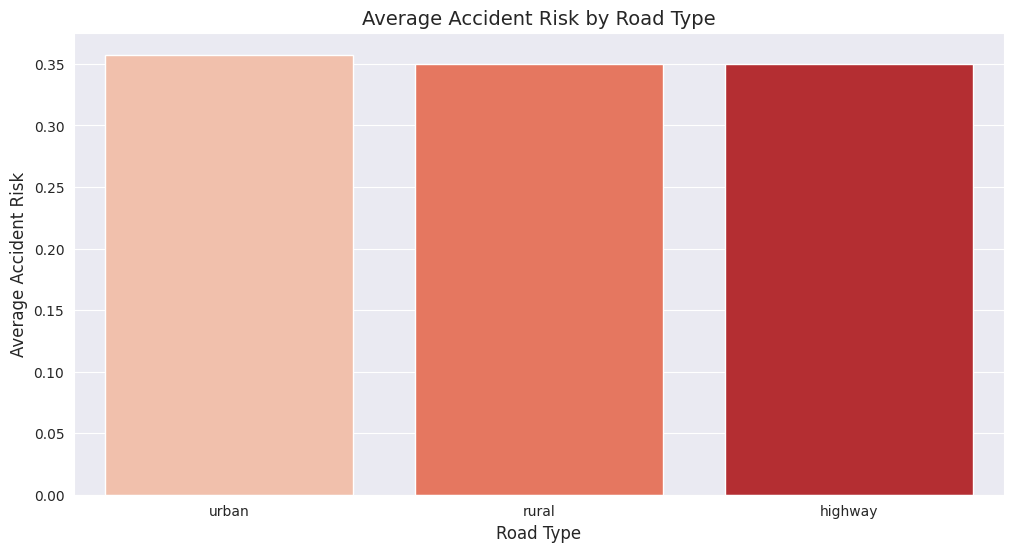


📊 INSIGHT: Road Type Analysis
  Highest Risk: urban (0.3575)
  Lowest Risk: highway (0.3497)
  Risk Range: 0.0077


In [10]:
# Figure 2: Accident Risk by Road Type
risk_by_road = df.groupby('road_type').agg({
    'accident_risk': 'mean',
    'num_reported_accidents': 'sum'
}).reset_index().sort_values('accident_risk', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(data=risk_by_road, x='road_type', y='accident_risk', palette='Reds')
plt.title('Average Accident Risk by Road Type')
plt.xlabel('Road Type')
plt.ylabel('Average Accident Risk')
plt.show()

print("\n📊 INSIGHT: Road Type Analysis")
print(f"  Highest Risk: {risk_by_road.iloc[0]['road_type']} ({risk_by_road.iloc[0]['accident_risk']:.4f})")
print(f"  Lowest Risk: {risk_by_road.iloc[-1]['road_type']} ({risk_by_road.iloc[-1]['accident_risk']:.4f})")
print(f"  Risk Range: {(risk_by_road.iloc[0]['accident_risk'] - risk_by_road.iloc[-1]['accident_risk']):.4f}")


### Accident Risk by Time of Day

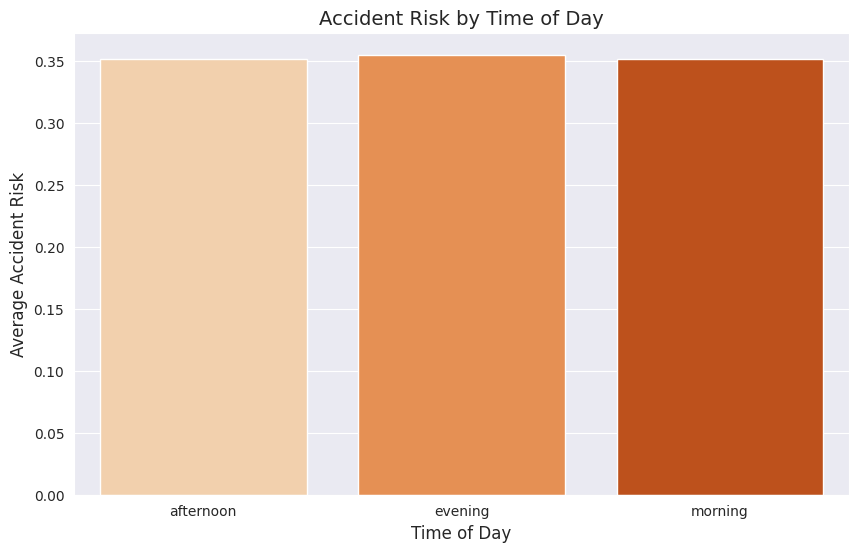

In [11]:
# Figure 3: Accident Risk by Time of Day
risk_by_time = df.groupby('time_of_day').agg({
    'accident_risk': 'mean',
    'num_reported_accidents': 'sum'
}).reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=risk_by_time, x='time_of_day', y='accident_risk', palette='Oranges')
plt.title('Accident Risk by Time of Day')
plt.xlabel('Time of Day')
plt.ylabel('Average Accident Risk')
plt.show()

### Accident Risk by Weather

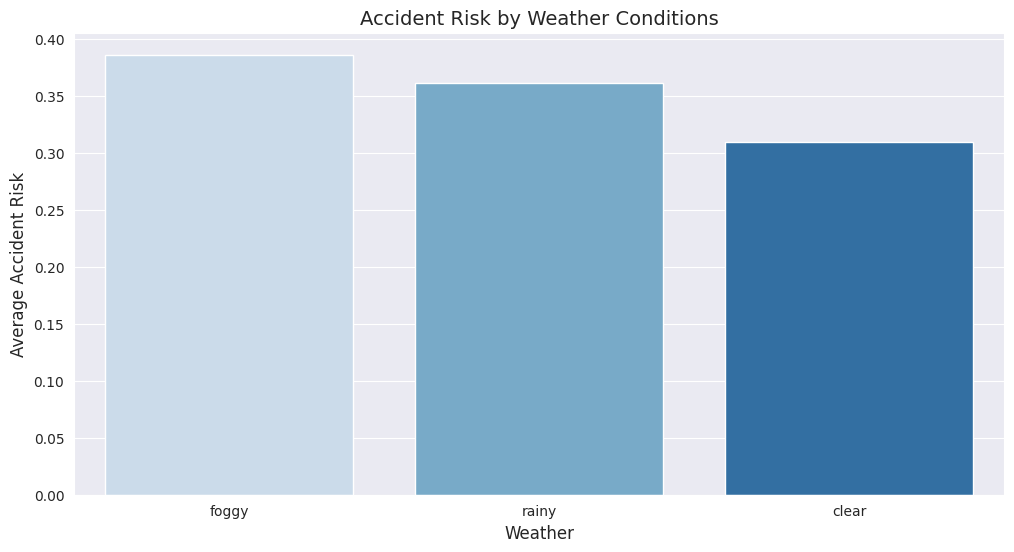


🌦️ INSIGHT: Weather Impact
  foggy: 0.3863 risk, 215800 accidents
  rainy: 0.3615 risk, 194582 accidents
  clear: 0.3101 risk, 204694 accidents


In [12]:
# Figure 4: Accident Risk by Weather
risk_by_weather = df.groupby('weather').agg({
    'accident_risk': 'mean',
    'num_reported_accidents': 'sum'
}).reset_index().sort_values('accident_risk', ascending=False)

plt.figure(figsize=(12,6))
sns.barplot(data=risk_by_weather, x='weather', y='accident_risk', palette='Blues')
plt.title('Accident Risk by Weather Conditions')
plt.xlabel('Weather')
plt.ylabel('Average Accident Risk')
plt.show()

print("\n🌦️ INSIGHT: Weather Impact")
for idx, row in risk_by_weather.iterrows():
    print(f"  {row['weather']}: {row['accident_risk']:.4f} risk, {row['num_reported_accidents']} accidents")


### Accident Risk by Lighting Conditions

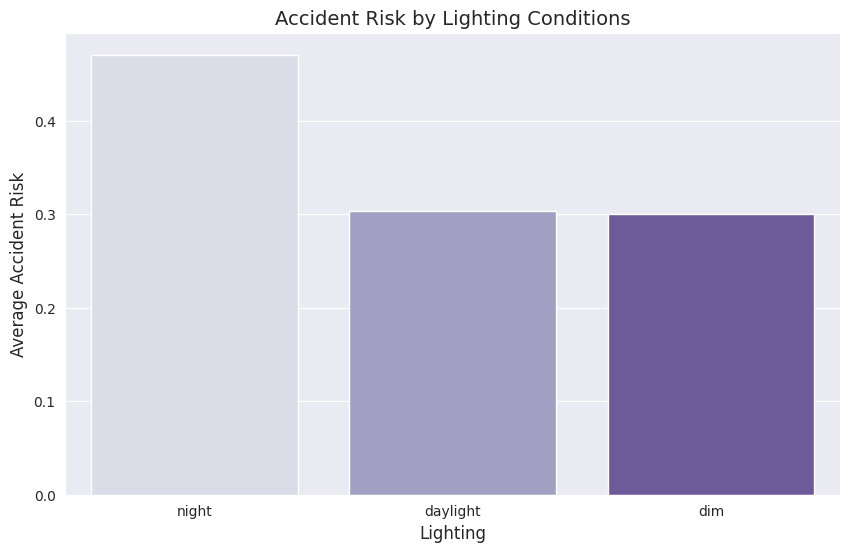

In [13]:
# Figure 5: Accident Risk by Lighting Conditions
risk_by_lighting = df.groupby('lighting').agg({
    'accident_risk': 'mean',
    'num_reported_accidents': 'sum'
}).reset_index().sort_values('accident_risk', ascending=False)

plt.figure(figsize=(10,6))
sns.barplot(data=risk_by_lighting, x='lighting', y='accident_risk', palette='Purples')
plt.title('Accident Risk by Lighting Conditions')
plt.xlabel('Lighting')
plt.ylabel('Average Accident Risk')
plt.show()

### Accident Risk Distribution by Speed Limit

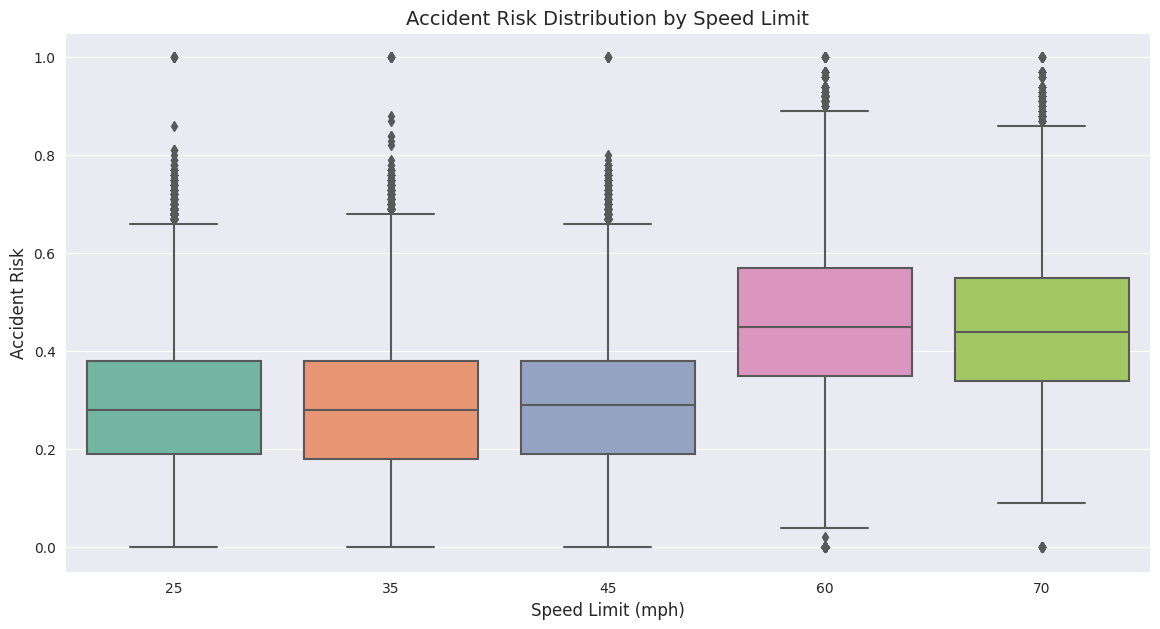


🚦 INSIGHT: Speed Limit Analysis
  25 mph: 0.2918 average risk
  35 mph: 0.2879 average risk
  45 mph: 0.2928 average risk
  60 mph: 0.4666 average risk
  70 mph: 0.4514 average risk


In [14]:
# Figure 6: Accident Risk Distribution by Speed Limit
plt.figure(figsize=(14,7))
sns.boxplot(data=df, x='speed_limit', y='accident_risk', palette='Set2')
plt.title('Accident Risk Distribution by Speed Limit')
plt.xlabel('Speed Limit (mph)')
plt.ylabel('Accident Risk')
plt.show()

risk_by_speed = df.groupby('speed_limit')['accident_risk'].mean().sort_index()
print("\n🚦 INSIGHT: Speed Limit Analysis")
for speed, risk in risk_by_speed.items():
    print(f"  {speed} mph: {risk:.4f} average risk")


### Number of Lanes Impact

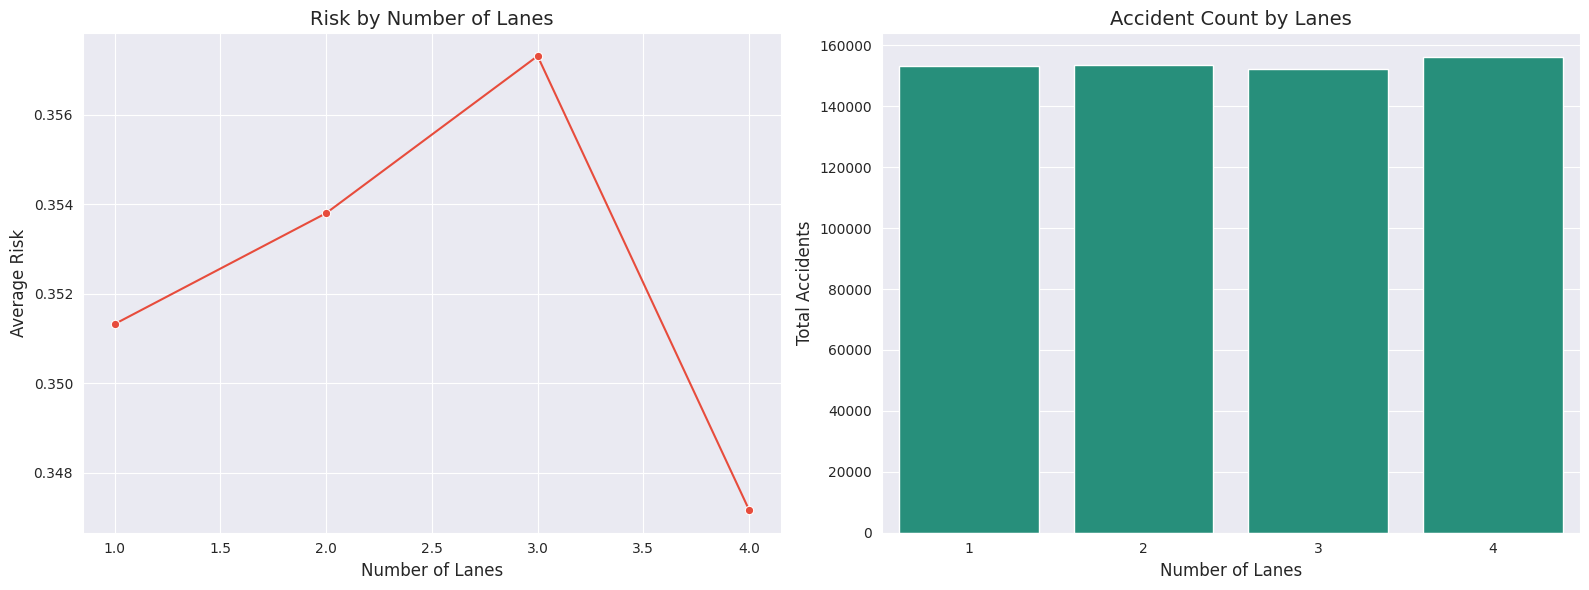

In [15]:
# Figure 7: Number of Lanes Impact
risk_by_lanes = df.groupby('num_lanes').agg({
    'accident_risk': 'mean',
    'num_reported_accidents': 'sum',
    'id': 'count'
}).reset_index()
risk_by_lanes.columns = ['num_lanes', 'avg_risk', 'total_accidents', 'count']

fig, axes = plt.subplots(1,2, figsize=(16,6))
sns.lineplot(data=risk_by_lanes, x='num_lanes', y='avg_risk', marker='o', color='#E74C3C', ax=axes[0])
axes[0].set_title('Risk by Number of Lanes')
axes[0].set_xlabel('Number of Lanes')
axes[0].set_ylabel('Average Risk')

sns.barplot(data=risk_by_lanes, x='num_lanes', y='total_accidents', color='#16A085', ax=axes[1])
axes[1].set_title('Accident Count by Lanes')
axes[1].set_xlabel('Number of Lanes')
axes[1].set_ylabel('Total Accidents')
plt.tight_layout()
plt.show()


### Road Curvature Analysis

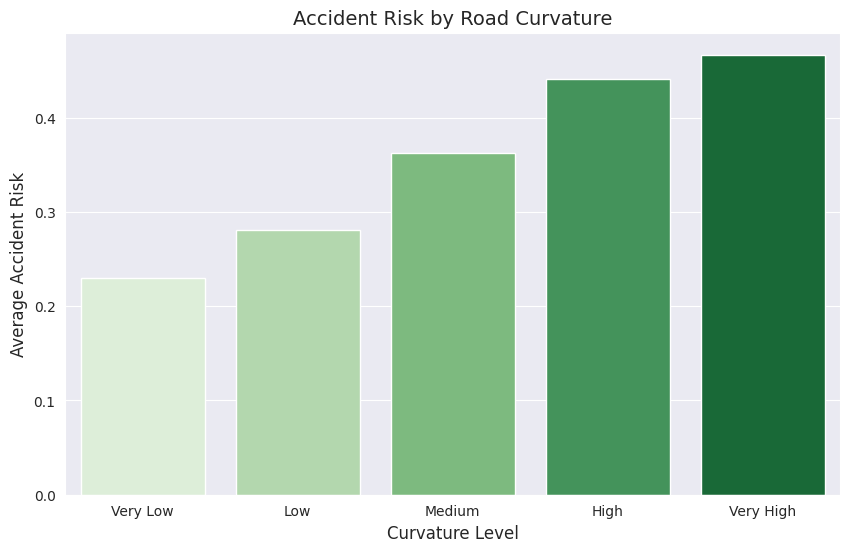

In [16]:
# Figure 8: Road Curvature Analysis
df['curvature_category'] = pd.cut(df['curvature'], bins=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
risk_by_curve = df.groupby('curvature_category')['accident_risk'].mean().reset_index()

plt.figure(figsize=(10,6))
sns.barplot(data=risk_by_curve, x='curvature_category', y='accident_risk', palette='Greens')
plt.title('Accident Risk by Road Curvature')
plt.xlabel('Curvature Level')
plt.ylabel('Average Accident Risk')
plt.show()

### Boolean Features Analysis"

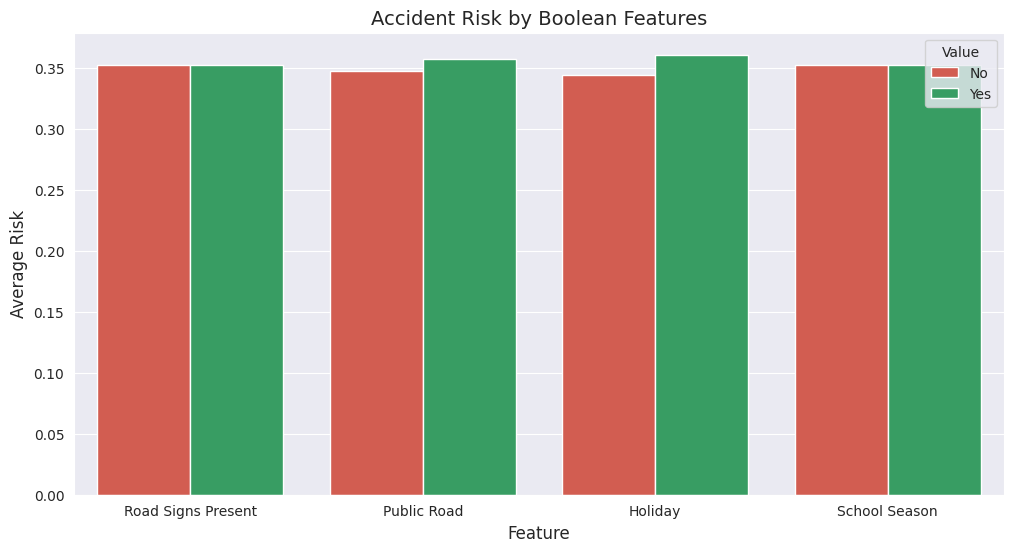


🚧 INSIGHT: Safety Features Impact
  Road Signs Present:
    With: 0.3525 | Without: 0.3523 | Diff: +0.0002
  Public Road:
    With: 0.3575 | Without: 0.3472 | Diff: +0.0103
  Holiday:
    With: 0.3608 | Without: 0.3438 | Diff: +0.0170
  School Season:
    With: 0.3522 | Without: 0.3525 | Diff: -0.0003


In [17]:
# Figure 9: Boolean Features Analysis
bool_features = ['road_signs_present', 'public_road', 'holiday', 'school_season']
bool_analysis = []

for feature in bool_features:
    stats = df.groupby(feature)['accident_risk'].agg(['mean', 'count']).reset_index()
    for idx, row in stats.iterrows():
        bool_analysis.append({
            'Feature': feature.replace('_', ' ').title(),
            'Value': 'Yes' if row[feature] else 'No',
            'Avg Risk': row['mean'],
            'Count': row['count']
        })

bool_df = pd.DataFrame(bool_analysis)

plt.figure(figsize=(12,6))
sns.barplot(data=bool_df, x='Feature', y='Avg Risk', hue='Value', palette={'Yes':'#27AE60', 'No':'#E74C3C'})
plt.title('Accident Risk by Boolean Features')
plt.xlabel('Feature')
plt.ylabel('Average Risk')
plt.legend(title='Value')
plt.show()

print("\n🚧 INSIGHT: Safety Features Impact")
for feature in bool_features:
    with_feature = df[df[feature] == True]['accident_risk'].mean()
    without_feature = df[df[feature] == False]['accident_risk'].mean()
    diff = with_feature - without_feature
    print(f"  {feature.replace('_', ' ').title()}:")
    print(f"    With: {with_feature:.4f} | Without: {without_feature:.4f} | Diff: {diff:+.4f}")


### Correlation Heatmap

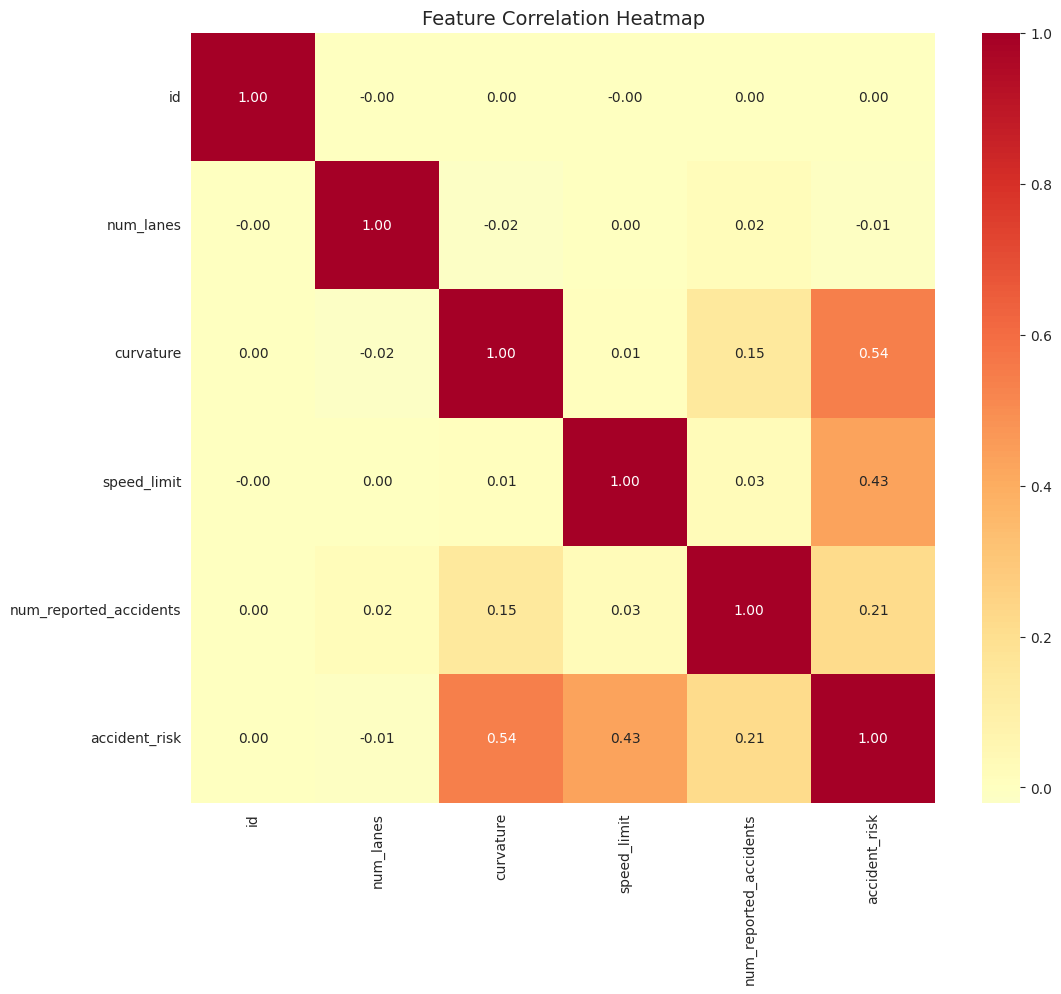


🔗 INSIGHT: Key Correlations with Accident Risk
accident_risk             1.000000
curvature                 0.543946
speed_limit               0.430898
num_reported_accidents    0.213891
id                        0.000969
num_lanes                -0.006003
Name: accident_risk, dtype: float64


In [18]:
# Figure 10: Correlation Heatmap
numeric_cols = df.select_dtypes(include=[np.number]).columns
correlation = df[numeric_cols].corr()

plt.figure(figsize=(12,10))
sns.heatmap(correlation, annot=True, cmap='RdYlBu_r', center=0, fmt=".2f")
plt.title('Feature Correlation Heatmap')
plt.show()

print("\n🔗 INSIGHT: Key Correlations with Accident Risk")
risk_corr = correlation['accident_risk'].sort_values(ascending=False)
print(risk_corr)

### MULTI-DIMENSIONAL ANALYSIS


SECTION 3: MULTI-DIMENSIONAL ANALYSIS


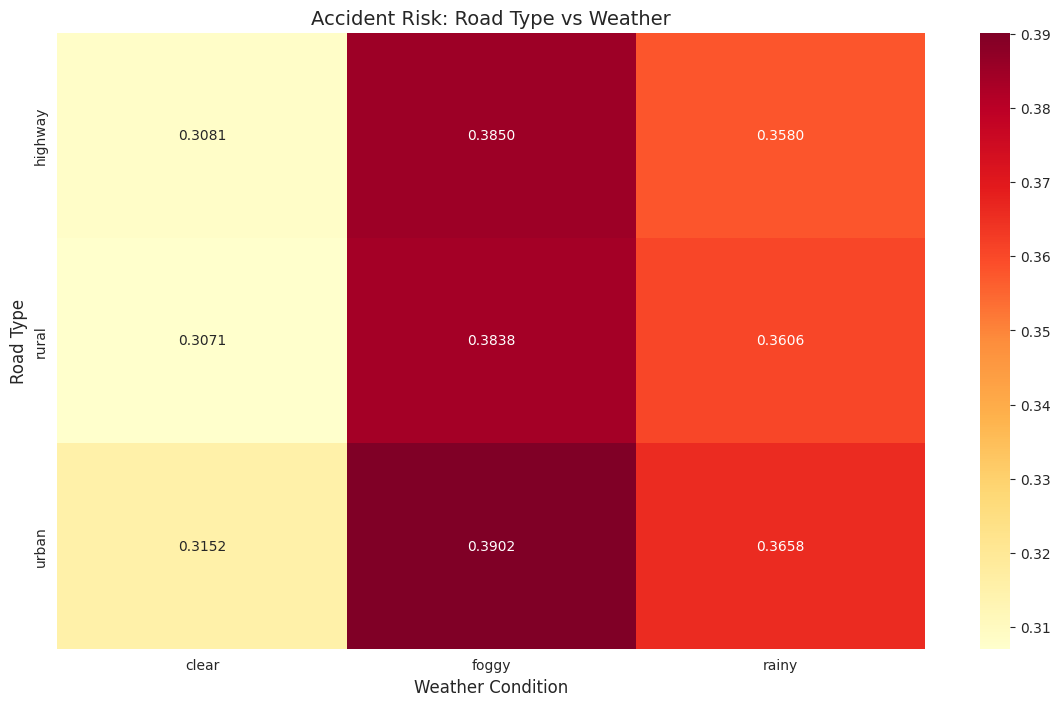

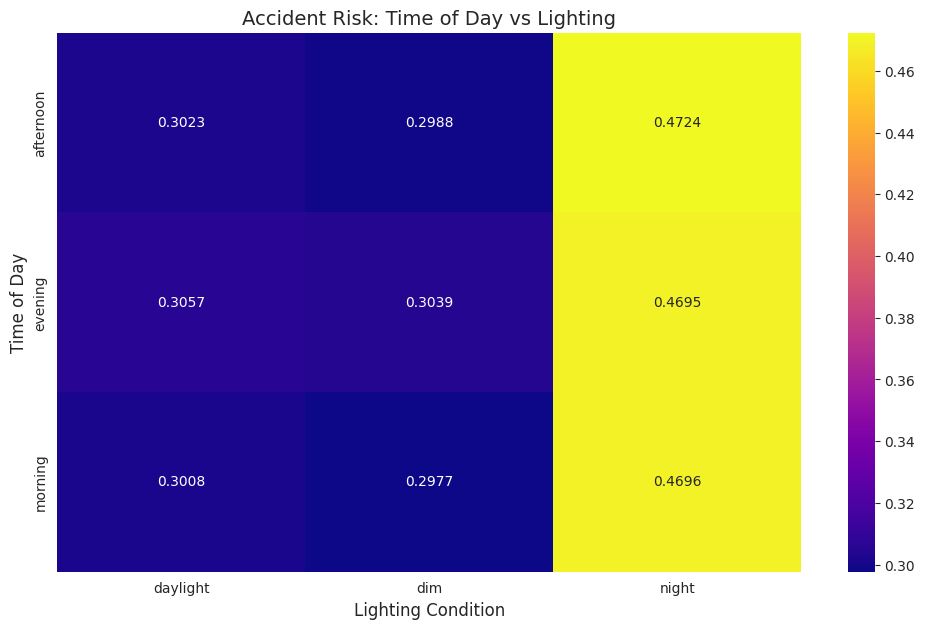

In [19]:
# ============================================================================
# MULTI-DIMENSIONAL ANALYSIS
# ============================================================================
print("\n" + "="*80)
print("SECTION 3: MULTI-DIMENSIONAL ANALYSIS")
print("="*80)

# Combined analysis: Road Type + Weather
pivot_road_weather = df.pivot_table(
    values='accident_risk',
    index='road_type',
    columns='weather',
    aggfunc='mean'
)

plt.figure(figsize=(14,8))
sns.heatmap(pivot_road_weather, annot=True, fmt=".4f", cmap="YlOrRd")
plt.title('Accident Risk: Road Type vs Weather')
plt.xlabel('Weather Condition')
plt.ylabel('Road Type')
plt.show()

# Time of day + Lighting
pivot_time_light = df.pivot_table(
    values='accident_risk',
    index='time_of_day',
    columns='lighting',
    aggfunc='mean'
)

plt.figure(figsize=(12,7))
sns.heatmap(pivot_time_light, annot=True, fmt=".4f", cmap="plasma")
plt.title('Accident Risk: Time of Day vs Lighting')
plt.xlabel('Lighting Condition')
plt.ylabel('Time of Day')
plt.show()

### BUSINESS INSIGHTS & RECOMMENDATIONS

In [20]:
# ============================================================================
# BUSINESS INSIGHTS & RECOMMENDATIONS
# ============================================================================
print("\n" + "="*80)
print("SECTION 4: KEY FINDINGS & RECOMMENDATIONS")
print("="*80)

print("\n🎯 TOP 5 HIGHEST RISK SCENARIOS:")
high_risk = df.nlargest(5, 'accident_risk')[['road_type', 'weather', 'time_of_day', 'lighting', 'num_lanes', 'speed_limit', 'accident_risk']]
for idx, row in high_risk.iterrows():
    print(f"\n  Scenario {idx+1}:")
    print(f"    Risk Score: {row['accident_risk']:.4f}")
    print(f"    Road: {row['road_type']} | Lanes: {row['num_lanes']} | Speed: {row['speed_limit']} mph")
    print(f"    Conditions: {row['weather']} | {row['lighting']} | {row['time_of_day']}")

print("\n\n💡 STRATEGIC RECOMMENDATIONS:")

# Recommendation 1: Highest risk road types
top_risk_roads = df.groupby('road_type')['accident_risk'].mean().nlargest(3)
print("\n1. PRIORITIZE SAFETY IMPROVEMENTS ON:")
for road, risk in top_risk_roads.items():
    count = len(df[df['road_type'] == road])
    accidents = df[df['road_type'] == road]['num_reported_accidents'].sum()
    print(f"   • {road}: {risk:.4f} risk | {count:,} segments | {accidents:,} accidents")

# Recommendation 2: Weather-based alerts
severe_weather = df.groupby('weather')['accident_risk'].mean().nlargest(2)
print("\n2. IMPLEMENT WEATHER-BASED ALERTS FOR:")
for weather, risk in severe_weather.items():
    print(f"   • {weather} conditions: {risk:.4f} risk")

# Recommendation 3: Road signs impact
sign_impact = df[df['road_signs_present'] == False]['accident_risk'].mean() - df[df['road_signs_present'] == True]['accident_risk'].mean()
print(f"\n3. ROAD SIGNAGE PROGRAM:")
print(f"   • Risk reduction with signs: {-sign_impact:.4f}")
print(f"   • Segments without signs: {len(df[df['road_signs_present'] == False]):,}")
print(f"   • Potential impact: HIGH PRIORITY")

# Recommendation 4: Time-based enforcement
time_risk = df.groupby('time_of_day')['accident_risk'].mean().nlargest(2)
print("\n4. ENHANCED ENFORCEMENT DURING:")
for time, risk in time_risk.items():
    print(f"   • {time}: {risk:.4f} risk")

# Recommendation 5: Speed limit analysis
high_speed_risk = df[df['speed_limit'] >= 60]['accident_risk'].mean()
low_speed_risk = df[df['speed_limit'] < 60]['accident_risk'].mean()
print(f"\n5. SPEED MANAGEMENT:")
print(f"   • High speed (≥60 mph) risk: {high_speed_risk:.4f}")
print(f"   • Lower speed (<60 mph) risk: {low_speed_risk:.4f}")
print(f"   • Consider speed reduction on high-risk segments")

print("\n" + "="*80)
print("END OF ANALYSIS")
print("="*80)


SECTION 4: KEY FINDINGS & RECOMMENDATIONS

🎯 TOP 5 HIGHEST RISK SCENARIOS:

  Scenario 2602:
    Risk Score: 1.0000
    Road: rural | Lanes: 3 | Speed: 35 mph
    Conditions: rainy | dim | evening

  Scenario 8898:
    Risk Score: 1.0000
    Road: rural | Lanes: 1 | Speed: 25 mph
    Conditions: rainy | night | morning

  Scenario 10397:
    Risk Score: 1.0000
    Road: urban | Lanes: 2 | Speed: 60 mph
    Conditions: foggy | night | afternoon

  Scenario 24484:
    Risk Score: 1.0000
    Road: highway | Lanes: 3 | Speed: 45 mph
    Conditions: foggy | dim | morning

  Scenario 30044:
    Risk Score: 1.0000
    Road: rural | Lanes: 1 | Speed: 35 mph
    Conditions: rainy | night | evening


💡 STRATEGIC RECOMMENDATIONS:

1. PRIORITIZE SAFETY IMPROVEMENTS ON:
   • urban: 0.3575 risk | 171,363 segments | 204,373 accidents
   • rural: 0.3500 risk | 172,719 segments | 204,172 accidents
   • highway: 0.3497 risk | 173,672 segments | 206,531 accidents

2. IMPLEMENT WEATHER-BASED ALERTS FOR:


In [21]:
# -------------------------
# Detect target
# -------------------------
possible_targets = ["accident_risk", "target", "y", "label", "accident_risk_score"]
target_col = None
for c in train.columns:
    if c.lower() in possible_targets:
        target_col = c
        break

if target_col is None:
    # Try variants
    for t in possible_targets:
        if t in train.columns:
            target_col = t
            break

if target_col is None:
    print("WARNING: No clear target column detected in train.csv. Expected 'accident_risk'.")
    print("Columns available:", list(train.columns)[:40])
    # Continue with EDA/FE but skip modeling steps later.
else:
    print("Detected target column:", target_col)
    
# -------------------------
# Feature Engineering
# -------------------------
def preprocess(df, is_train=True):
    df = df.copy()
    # Boolean to int
    for c in df.select_dtypes(include=["bool"]).columns:
        df[c] = df[c].astype(int)

    # Time of day encoding
    if "time_of_day" in df.columns:
        try:
            if df["time_of_day"].dtype == "object":
                hours = df["time_of_day"].str.extract(r"^(\d{1,2})").astype(float)
                df["hour"] = hours.values.squeeze()
            else:
                df["hour"] = df["time_of_day"].astype(float)
            df["hour_sin"] = np.sin(2 * np.pi * df["hour"] / 24)
            df["hour_cos"] = np.cos(2 * np.pi * df["hour"] / 24)
        except:
            pass

    # Interaction features
    if {"num_lanes", "speed_limit"}.issubset(df.columns):
        df["lane_speed"] = df["num_lanes"] * df["speed_limit"]
    if {"curvature", "speed_limit"}.issubset(df.columns):
        df["curv_speed_ratio"] = df["curvature"] / (df["speed_limit"] + 1e-6)

    # Encode categoricals
    for c in df.select_dtypes(include=["object", "category"]).columns:
        df[c] = df[c].fillna("##MISSING##").astype(str)
        le = LabelEncoder()
        df[c] = le.fit_transform(df[c])

    # Fill numeric missing
    for c in df.select_dtypes(include=[np.number]).columns:
        if df[c].isna().sum()>0:
            df[c] = df[c].fillna(df[c].median())

    return df

train_proc = preprocess(train, is_train=True)
test_proc = preprocess(test, is_train=False) if test is not None else None

print("Feature engineering done. Example columns:", train_proc.columns[:20])

# -------------------------
# Modeling
# -------------------------
if target_col is None:
    print("No target found — skipping model training.")
else:
    features = [c for c in train_proc.columns if c not in ("id", target_col)]
    X = train_proc[features].copy()
    y = train_proc[target_col].values

    # Scale numeric features
    scaler = StandardScaler()
    num_feats = X.select_dtypes(include=[np.number]).columns.tolist()
    X[num_feats] = scaler.fit_transform(X[num_feats])
    if test_proc is not None:
        test_proc[num_feats] = scaler.transform(test_proc[num_feats])

    # Cross-validation LightGBM
    NFOLD = 5
    kf = KFold(n_splits=NFOLD, shuffle=True, random_state=42)
    oof_preds = np.zeros(len(X))
    feature_importances = pd.DataFrame({"feature": X.columns})
    models = []
    cv_scores = []

    lgb_params = {
        "objective": "regression",
        "metric": "rmse",
        "boosting": "gbdt",
        "learning_rate": 0.05,
        "num_leaves": 31,
        "min_data_in_leaf": 50,
        "feature_fraction": 0.8,
        "bagging_fraction": 0.8,
        "bagging_freq": 5,
        "verbosity": -1,
        "seed": 42,
    }

    fold = 0
    for tr_idx, val_idx in kf.split(X, y):
        fold += 1
        print(f"Fold {fold}")
        X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
        y_tr, y_val = y[tr_idx], y[val_idx]

        tr_data = lgb.Dataset(X_tr, label=y_tr)
        val_data = lgb.Dataset(X_val, label=y_val)

        model = lgb.train(
            lgb_params,
            tr_data,
            valid_sets=[tr_data, val_data],
            valid_names=["train","valid"],
            num_boost_round=10000,
            callbacks=[
                lgb.early_stopping(200),
                lgb.log_evaluation(200)
            ]
        )

        models.append(model)
        val_pred = model.predict(X_val, num_iteration=model.best_iteration)
        oof_preds[val_idx] = val_pred
        rmse = mean_squared_error(y_val, val_pred, squared=False)
        cv_scores.append(rmse)
        print(f"Fold {fold} RMSE: {rmse:.6f}")

        feature_importances[f"fold_{fold}"] = model.feature_importance(importance_type="gain")
        gc.collect()

    mean_cv = np.mean(cv_scores)
    std_cv = np.std(cv_scores)
    print(f"\nCV RMSE mean: {mean_cv:.6f} std: {std_cv:.6f}")

    # Save feature importances
    feature_importances["importance_mean"] = feature_importances[[c for c in feature_importances.columns if c.startswith("fold_")]].mean(axis=1)
    feature_importances = feature_importances.sort_values("importance_mean", ascending=False)
    feature_importances.to_csv(OUT_DIR / "feature_importances.csv", index=False)

    # Plot top features
    top_n = 30
    fi_plot = feature_importances.head(top_n).set_index("feature")["importance_mean"].sort_values()
    plt.figure(figsize=(8, max(4, 0.2*len(fi_plot))))
    fi_plot.plot(kind="barh")
    plt.title("Top feature importances (mean gain)")
    plt.tight_layout()
    plt.savefig(OUT_DIR / "feature_importances.png")
    plt.close()

    # Train final model and predict test
    # Train final model and predict test
if test is not None:
    print("\nTraining final model on all data and predicting test set...")
    full_data = lgb.Dataset(X, label=y)
    final_model = lgb.train(
        lgb_params,
        full_data,
        num_boost_round=int(np.mean([m.best_iteration for m in models]) * 1.1),
        callbacks=[
            lgb.log_evaluation(200)
        ],
    )
    test_X = test_proc[features].copy()
    test_preds = final_model.predict(test_X, num_iteration=final_model.best_iteration)
    test_preds = np.clip(test_preds, 0.0, 1.0)

    # Submission
    if "id" in test.columns:
        sub = pd.DataFrame({"id": test["id"].astype(int), "accident_risk": test_preds})
    else:
        start_id = train["id"].max() + 1 if "id" in train.columns else 0
        sub = pd.DataFrame({"id": np.arange(start_id, start_id + len(test_preds)), "accident_risk": test_preds})
    submission_path = Path("/kaggle/working/submission.csv")
    sub.to_csv(submission_path, index=False)
    print("Submission saved to", submission_path)

# -------------------------
#  Report & Dashboard
# -------------------------
report_lines = []
report_lines.append("EDA & Modeling Report")
report_lines.append(f"Train shape: {train.shape}")
if test is not None:
    report_lines.append(f"Test shape: {test.shape}")
if target_col is not None:
    report_lines.append(f"Target: {target_col}")
if target_col is not None and 'mean_cv' in locals():
    report_lines.append(f"CV RMSE: {mean_cv:.6f} ± {std_cv:.6f}")
report_lines.append("\nFiles created in /kaggle/working/eda_outputs:\n")
for f in sorted(OUT_DIR.glob("*"))[:200]:
    report_lines.append(f"- {f.name}")
with open(OUT_DIR / "short_report.txt", "w") as f:
    f.write("\n".join(report_lines))

# Dashboard index
html = ["<html><head><meta charset='utf-8'><title>EDA Dashboard</title></head><body>"]
html.append("<h1>EDA & Modeling Outputs</h1>")
html.append("<ul>")
for f in sorted(OUT_DIR.glob("*")):
    html.append(f"<li><a href='{f.name}' target='_blank'>{f.name}</a></li>")
html.append("</ul>")
html.append("</body></html>")
with open(OUT_DIR / "index.html", "w") as f:
    f.write("\n".join(html))

print("\nAll done. Outputs in /kaggle/working/eda_outputs. Short report saved.")


Detected target column: accident_risk
Feature engineering done. Example columns: Index(['id', 'road_type', 'num_lanes', 'curvature', 'speed_limit', 'lighting',
       'weather', 'road_signs_present', 'public_road', 'time_of_day',
       'holiday', 'school_season', 'num_reported_accidents', 'accident_risk',
       'hour', 'hour_sin', 'hour_cos', 'lane_speed', 'curv_speed_ratio'],
      dtype='object')
Fold 1
Training until validation scores don't improve for 200 rounds
[200]	train's rmse: 0.0560381	valid's rmse: 0.0563996
[400]	train's rmse: 0.0557865	valid's rmse: 0.0563088
[600]	train's rmse: 0.0556049	valid's rmse: 0.0562806
[800]	train's rmse: 0.0554565	valid's rmse: 0.0562655
[1000]	train's rmse: 0.0553169	valid's rmse: 0.0562618
[1200]	train's rmse: 0.0551853	valid's rmse: 0.0562575
Early stopping, best iteration is:
[1191]	train's rmse: 0.0551899	valid's rmse: 0.0562565
Fold 1 RMSE: 0.056256
Fold 2
Training until validation scores don't improve for 200 rounds
[200]	train's rmse: 